In [1]:
# If needed:
# !pip install celltypist

from pathlib import Path
import tarfile

import pandas as pd
import matplotlib as mpl

import scanpy as sc
import anndata

import celltypist
from celltypist import models

import umap

/Users/lingting/ENTER/envs/mrvi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = Path('../..')

# Input paths
TCELL_RAW_PATH      = PROJECT_ROOT / 'published_data' / 'Tcell_raw_counts02_v2.h5ad'
TCELL_ANN_SC_PATH  = PROJECT_ROOT / 'adata_file' / 'tcell_ann_sc.h5ad'
GUT_ATLAS_PATH      = PROJECT_ROOT / 'published_data' / 'gut_atlas' / '4_Healthy_Pan-GI_atlas_TNK_20241119.h5ad'
MODEL_CD4_PATH      = PROJECT_ROOT / 'published_data' / 'model_from_own_cd4.pkl'
MODEL_CD8_PATH      = PROJECT_ROOT / 'published_data' / 'model_from_own_cd8_3_resi.pkl'
GSE152042_RAW_DIR   = PROJECT_ROOT / 'published_data' / 'GSE152042_RAW'
GSE157477_RAW_DIR   = PROJECT_ROOT / 'published_data' / 'GSE157477_RAW'
TCELL_ANN_CONCAT_REFINED_PATH = PROJECT_ROOT / 'adata_file' / 'tcell_ann_concat_Tcell_only_Migration_refined.h5ad'

GSM6443304_CSV      = PROJECT_ROOT / 'published_data' / 'GSM6443304_TFHS000025_annotation.csv'
GSM6443304_MTX      = PROJECT_ROOT / 'published_data' / 'GSM6443304_TFHS000025_matrix.mtx'
GSM6443304_BARCODES = PROJECT_ROOT / 'published_data' / 'GSM6443304_TFHS000025_barcodes.tsv.gz'
GSM6443304_FEATURES = PROJECT_ROOT / 'published_data' / 'GSM6443304_TFHS000025_features.tsv'

# Output paths
FIGURES_CT_DIR      = PROJECT_ROOT / 'Figures' / 'celltypist_figures'


In [3]:
FIGURES_CT_DIR.mkdir(parents=True, exist_ok=True)
sc.settings.figdir = str(FIGURES_CT_DIR)

In [4]:
####Gut single cell atlas
adata = sc.read_h5ad(TCELL_RAW_PATH)

print(adata)
adata = adata[adata.obs['Diagnosis'] == 'Healthy adult', :]

AnnData object with n_obs × n_vars = 38633 × 33538
    obs: 'Sample name', 'Diagnosis', 'Age', 'sample name', 'Region code', 'Fraction', 'Region', '10X', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_scores', 'predicted_doublets', 'S_score', 'G2M_score', 'phase', 'productive', 'annotation', 'Gender'
    var: 'gene_ids', 'feature_types'


In [5]:
adata.X.max()

15107.0

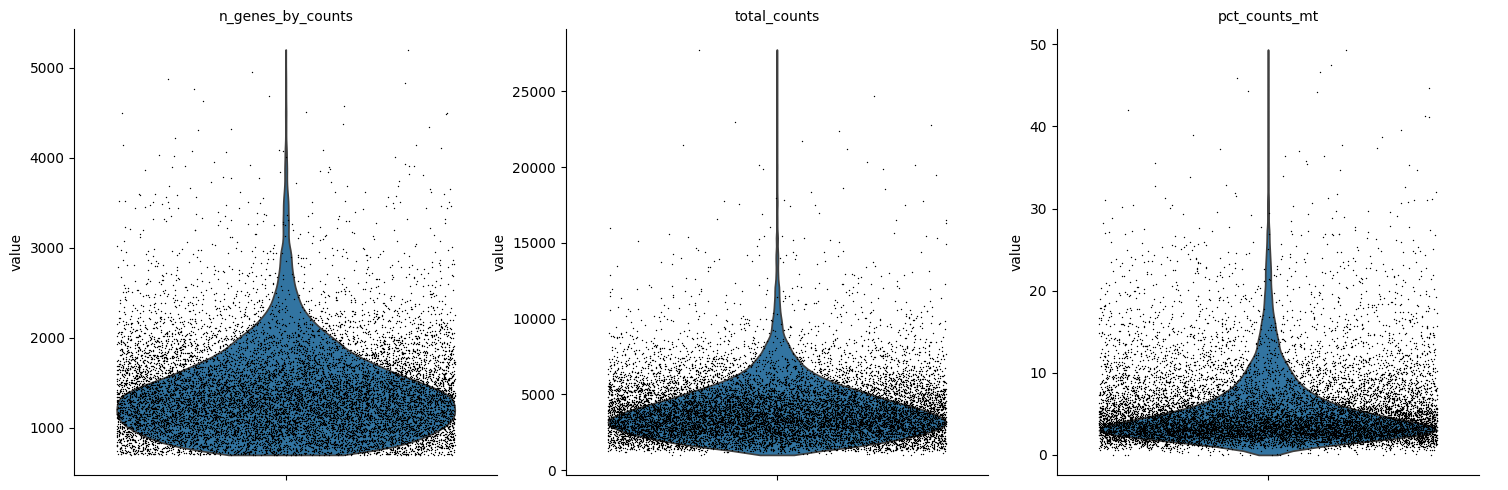

In [6]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

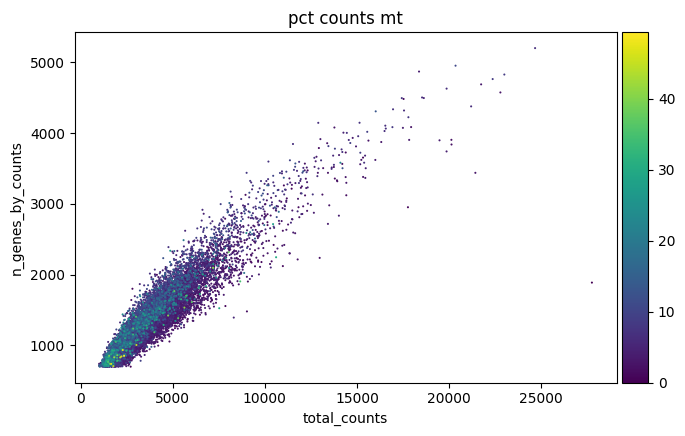

In [7]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [8]:
#preprocessing
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 10, :].copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [9]:
adata_own = sc.read_h5ad(TCELL_ANN_SC_PATH)

In [10]:
adata_own.X = adata_own.layers['counts']

In [11]:
adata_own.X.max()

4211.0

In [12]:
sc.pp.normalize_total(adata_own, target_sum=1e4)
sc.pp.log1p(adata_own)

In [13]:
adata_own

AnnData object with n_obs × n_vars = 38539 × 38012
    obs: 'PatientID', 'SampleID', 'FreshorFrozen', 'Days_post-Transplant', 'Tissue_Location', 'LPorIE', 'Enrichment Method', 'Pathological_grade_of_GVHD', 'Grade_num', 'GVHD_Grade_1', 'GVHD_Grade_2', 'GVHD_Grade_3', 'Transplant_Conditioning', 'Gender', 'DoT', 'Time_1stGVHD', 'Donor', 'Disease', 'GVHD_Prophylaxis_Regimen', 'Dates_from_Transplantation', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'is_doublet', 'leiden', 'leiden_0.15', 'B_doublet', 'Myeloid_doublet', 'Macrophage_doublet', 'Monocyte_doublet', 'Epithelial_doublet', 'Fibroblast_doublet', 'plasma_doublet2', 'if_doublet', 'T_cell_subsets'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'B_doublet_colors', 'Epithelial_doublet_colors', 'Fibroblast_doublet_colors', 'Macropha

In [14]:
tcell_ann_concat = sc.read_h5ad(TCELL_ANN_CONCAT_REFINED_PATH)

# Columns you want to transfer from Tcell_migration to the subset
cols_to_transfer = tcell_ann_concat.obs.columns.tolist()

cols_to_transfer = ['T_cell_subsets_refined_resi']

# Drop cols if they already exist in the subset to avoid conflicts
existing = [c for c in cols_to_transfer if c in adata_own.obs.columns]
adata_own.obs = adata_own.obs.drop(columns=existing)

# Transfer
adata_own.obs = adata_own.obs.join(
    tcell_ann_concat.obs[cols_to_transfer],
    how='left'
)

In [15]:


#IBD
#https://www.frontiersin.org/journals/immunology/articles/10.3389/fimmu.2022.977117/full#h6

csv_path = GSM6443304_CSV
matrix_path = GSM6443304_MTX
barcodes_path = GSM6443304_BARCODES
features_path = GSM6443304_FEATURES

# 1. Load the annotations CSV
adata2_annotations = pd.read_csv(csv_path)

# 2. Load the matrix file using scanpy and transpose it
adata2 = sc.read_mtx(matrix_path).T  # Transpose to have (n_cells, n_genes)


# 3. Load barcodes (cells)
adata2_barcodes = pd.read_csv(barcodes_path, header=None, compression='gzip', sep='\t')

# 4. Load features (genes)
adata2_features = pd.read_csv(features_path, header=None, sep='\t')

# 5. Set obs_names (cell barcodes) and var_names (gene names)
adata2.obs_names = adata2_barcodes[0].astype(str).values  # Ensure barcodes are strings
adata2.var_names = adata2_features[1].astype(str).values  # Ensure features are strings

adata2.var_names_make_unique()

#works above
adata2_annotations['extracted_barcode'] = adata2_annotations['barcode'].str.split('_', n=1).str[1]

# Get the barcodes from the annotations
annotation_barcodes = adata2_annotations['extracted_barcode'].values

# Create a boolean mask to filter the AnnData object
mask = adata2.obs_names.isin(annotation_barcodes)

# Filter the AnnData object to keep only rows (cells) that match the barcodes in annotations
adata2_filtered = adata2[mask].copy()  # Keep only matching rows

# Update obs_names for the filtered data
adata2_filtered.obs_names = adata2.obs_names[mask]

# Now, filter annotations to match the barcodes in the filtered matrix
# We will keep only the rows in annotations that match the filtered barcodes
filtered_annotations = adata2_annotations[adata2_annotations['extracted_barcode'].isin(adata2_filtered.obs_names)]

# Reset the index of the filtered annotations for proper alignment
filtered_annotations.reset_index(drop=True, inplace=True)

# Assign the filtered annotations to the filtered AnnData object
adata2_filtered.obs = filtered_annotations

# Final checks
print("Original number of cells:", adata2.n_obs)
print("Filtered number of cells:", adata2_filtered.n_obs)
print(adata2_filtered)

# If you want to keep the filtered adata2 as your main object
adata2 = adata2_filtered

print(adata2.X.max())
#preprocessing
sc.pp.filter_cells(adata2, min_genes=200)
sc.pp.filter_genes(adata2, min_cells=3)

sc.pp.normalize_total(adata2, target_sum=1e4)
sc.pp.log1p(adata2)

Original number of cells: 1265
Filtered number of cells: 1143
AnnData object with n_obs × n_vars = 1143 × 36601
    obs: 'barcode', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'vdj', 'cell_anno_GlobalPanel', 'cell_anno_MonacoPanel', 'cell_anno_NovershternPanel', 'cell_anno_CITESeqPanel', 'cell_anno_azimuth', 'sample_ID', 'cluster_anno_GlobalPanel', 'cluster_anno_MonacoPanel', 'cluster_anno_NovershternPanel', 'cluster_anno_CITESeqPanel', 'cluster_anno_azimuth', 'extracted_barcode'
12428.0


In [16]:

adata_own.obs['T_cell_subsets_refined_resi'] = adata_own.obs['T_cell_subsets_refined_resi'].astype(str)


In [17]:
cd4_annotations = ['CD4+ Effector Memory', 'Naive CD4+ T-cell']
adata2_Novershtern_cd4 = adata2[adata2.obs['cluster_anno_NovershternPanel'].isin(cd4_annotations)]

# Filter for CD8 annotations (Activated CD8 T, SELL+ CD8 T, gdT cells)
cd8_annotations = ['CD8+ Effector Memory', 'Naive CD8+ T-cell']
adata2_Novershtern_cd8 = adata2[adata2.obs['cluster_anno_NovershternPanel'].isin(cd8_annotations)]


In [18]:
cd4_annotations = ['CD4 TCM', 'CD4 TEM','Treg','CD4 Naive']
adata2_azimuth_cd4 = adata2[adata2.obs['cell_anno_azimuth'].isin(cd4_annotations)]

# Filter for CD8 annotations (Activated CD8 T, SELL+ CD8 T, gdT cells)
cd8_annotations = ['CD8 TEM', 'CD8 Naive', 'CD8 TCM']
adata2_azimuth_cd8 = adata2[adata2.obs['cell_anno_azimuth'].isin(cd8_annotations)]


In [19]:
cd4_annotations = ['Activated CD4 T', 'Treg', 'SELL+ CD4 T', 'Th17']
adata_cd4 = adata[adata.obs['annotation'].isin(cd4_annotations)]

# Filter for CD8 annotations (Activated CD8 T, SELL+ CD8 T, gdT cells)
cd8_annotations = ['Activated CD8 T', 'SELL+ CD8 T', 'TRGV5/7 gdT', 'gdT', 'CD8 Tem', 'TRGV4 gdT', 'TRGV2 gdT']
adata_cd8 = adata[adata.obs['annotation'].isin(cd8_annotations)]


In [20]:
# Define the updated annotation lists
cd4_annotations = ['CD4+ central memory T cells', 'CD4+ effector T cells', 'CD4+ regulatory T cells']
cd8_annotations = [
    'CD8+ effector T cells', 'CD8+ tissue resident memory T cells', 
    'CD8+ proliferating T cells', 'CD8+ cytotoxic unconventional T cells', 'CD8+ homeostatic unconventional T cells', 'CD8+ hobit+ transitional resident memory T cells', 'CD8+ hobit+ PRDM1 low resident memory T cells','CD8+ hobit- resident memory T cells',
]

# Filter for CD4 annotations
adata_own_cd4 = adata_own[adata_own.obs['T_cell_subsets_refined_resi'].isin(cd4_annotations)]

# Filter for CD8 annotations
adata_own_cd8 = adata_own[adata_own.obs['T_cell_subsets_refined_resi'].isin(cd8_annotations)]


In [21]:
adata_own_cd4.obs['T_cell_subsets_refined_resi'].value_counts()

T_cell_subsets_refined_resi
CD4+ effector T cells          7216
CD4+ central memory T cells    2824
CD4+ regulatory T cells        1795
Name: count, dtype: int64

In [22]:
adata_own_cd8.obs['T_cell_subsets_refined_resi'].value_counts()

T_cell_subsets_refined_resi
CD8+ effector T cells                               8017
CD8+ cytotoxic unconventional T cells               3844
CD8+ proliferating T cells                          2884
CD8+ tissue resident memory T cells                 2011
CD8+ hobit- resident memory T cells                 1736
CD8+ homeostatic unconventional T cells             1373
CD8+ hobit+ PRDM1 low resident memory T cells        838
CD8+ hobit+ transitional resident memory T cells     524
Name: count, dtype: int64

In [23]:
#model_cd4 = celltypist.train(adata_own_cd4, labels = 'T_cell_subsets_refined_resi', n_jobs = 10, feature_selection = True)

In [24]:
#model_cd8 = celltypist.train(adata_own_cd8, labels = 'T_cell_subsets_refined_resi', n_jobs = 10, feature_selection = True)

In [25]:
#model_cd4.write(MODEL_CD4_PATH)
model_cd4 = models.Model.load(str(MODEL_CD4_PATH))
predictions_cd4 = celltypist.annotate(adata_cd4, model=model_cd4, majority_voting=False)
adata_predictions_cd4 = predictions_cd4.to_adata()

🔬 Input data has 6495 cells and 18906 genes
🔗 Matching reference genes in the model
🧬 622 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


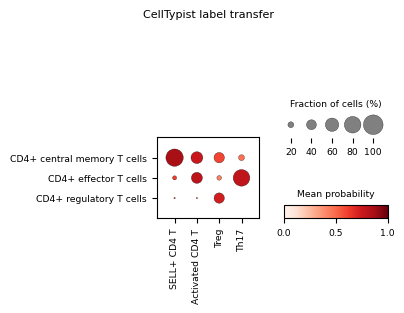

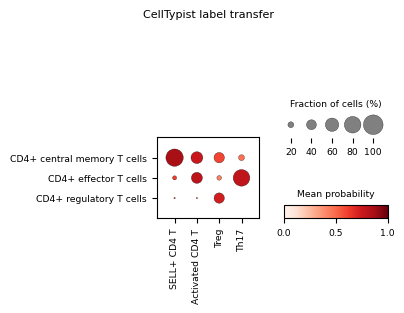

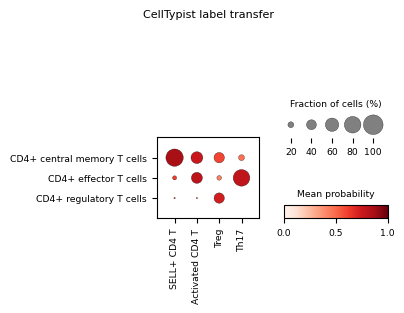

In [26]:

mpl.rcParams['image.cmap'] = 'viridis'  # Or your preferred colormap
mpl.rcParams.update({'font.size': 8, 'svg.fonttype': 'none'})
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['xtick.labelsize'] = 8  # Colorbar tick label size 
mpl.rcParams['ytick.labelsize'] = 8  # Colorbar tick label size

predicted_labels = predictions_cd4.predicted_labels
predicted_labels['predicted_labels'] = predicted_labels['predicted_labels'].astype('category')
celltypist.dotplot(predictions_cd4, use_as_reference='annotation', use_as_prediction='predicted_labels', cmap='Reds', save = "cd4_gutatlas.png")
celltypist.dotplot(predictions_cd4, use_as_reference='annotation', use_as_prediction='predicted_labels', cmap='Reds', save = "cd4_gutatlas.svg")
celltypist.dotplot(predictions_cd4, use_as_reference='annotation', use_as_prediction='predicted_labels', cmap='Reds', save = "cd4_gutatlas.pdf")


🔬 Input data has 723 cells and 13651 genes
🔗 Matching reference genes in the model
🧬 608 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


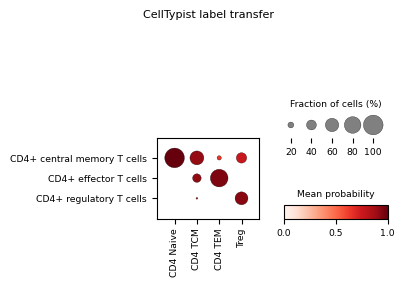

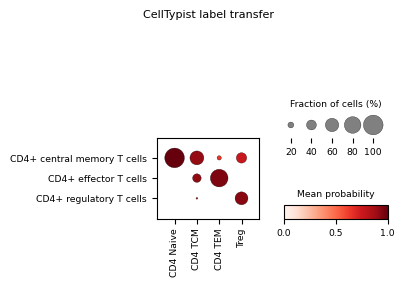

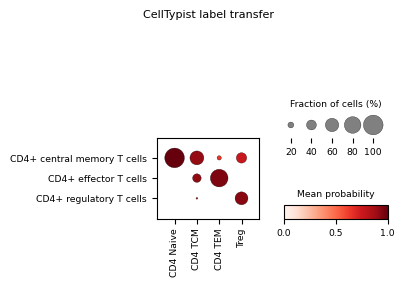

In [27]:
predictions_cd4 = celltypist.annotate(adata2_azimuth_cd4, model=model_cd4, majority_voting=False)
adata_predictions_cd4 = predictions_cd4.to_adata()
celltypist.dotplot(predictions_cd4, use_as_reference = 'cell_anno_azimuth', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd4_azimuth.png") 
celltypist.dotplot(predictions_cd4, use_as_reference = 'cell_anno_azimuth', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd4_azimuth.pdf") 
celltypist.dotplot(predictions_cd4, use_as_reference = 'cell_anno_azimuth', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd4_azimuth.svg") 

🔬 Input data has 704 cells and 13651 genes


🔗 Matching reference genes in the model
🧬 608 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


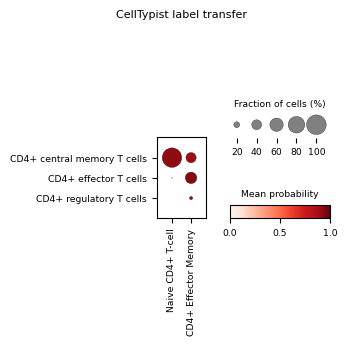

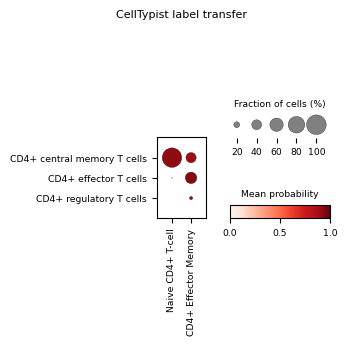

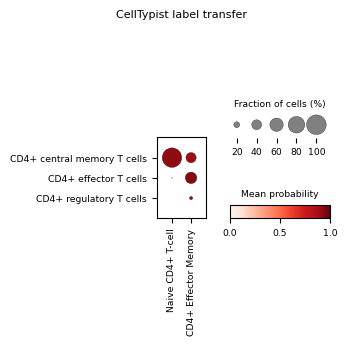

In [28]:
predictions_cd4 = celltypist.annotate(adata2_Novershtern_cd4, model=model_cd4, majority_voting=False)
adata_predictions_cd4 = predictions_cd4.to_adata()

celltypist.dotplot(predictions_cd4, use_as_reference = 'cluster_anno_NovershternPanel', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd4_novershtern.png") 
celltypist.dotplot(predictions_cd4, use_as_reference = 'cluster_anno_NovershternPanel', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd4_novershtern.pdf") 
celltypist.dotplot(predictions_cd4, use_as_reference = 'cluster_anno_NovershternPanel', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd4_novershtern.svg") 

🔬 Input data has 3875 cells and 18906 genes
🔗 Matching reference genes in the model
🧬 1259 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


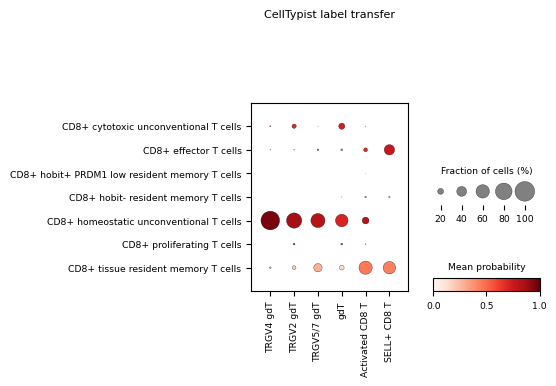

In [29]:
#model_cd8.write(MODEL_CD8_PATH)
model_cd8 = models.Model.load(str(MODEL_CD8_PATH))
predictions_cd8 = celltypist.annotate(adata_cd8, model=model_cd8, majority_voting=False)
adata_predictions_cd8 = predictions_cd8.to_adata()
celltypist.dotplot(predictions_cd8, use_as_reference = 'annotation', use_as_prediction = 'predicted_labels',cmap='Reds') 

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


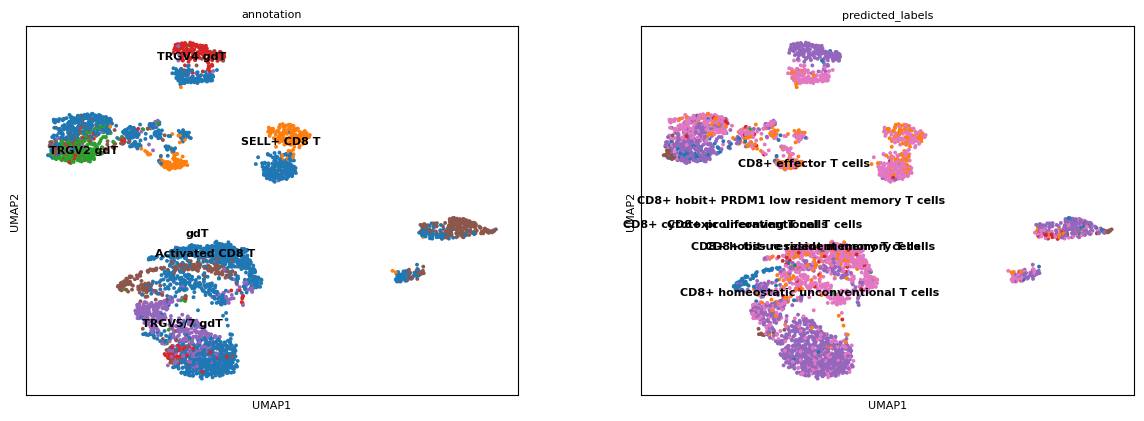

In [30]:

sc.pp.neighbors(adata_predictions_cd8, random_state=0)
sc.tl.umap(adata_predictions_cd8, random_state=0)
sc.pl.umap(adata_predictions_cd8, color = ['annotation', 'predicted_labels'], legend_loc = 'on data')

... storing 'T_cell_subsets_refined_resi' as categorical


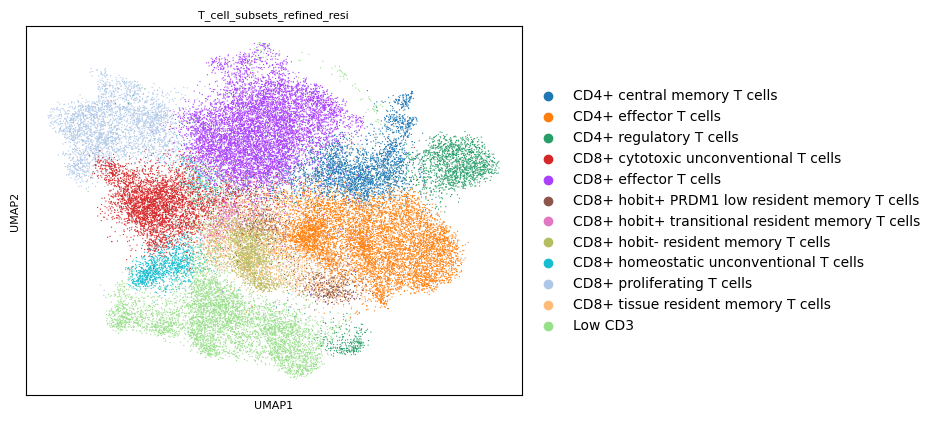

In [31]:

sc.pl.umap(
    adata_own,
    color=['T_cell_subsets_refined_resi'],
    legend_loc='right margin',
    legend_fontsize=10  # Adjust the font size (e.g., 10 for smaller fonts)
)

In [32]:
adata_predictions_cd8.obs['predicted_labels'].value_counts()


predicted_labels
CD8+ tissue resident memory T cells              1637
CD8+ homeostatic unconventional T cells          1547
CD8+ effector T cells                             388
CD8+ cytotoxic unconventional T cells             168
CD8+ hobit- resident memory T cells                77
CD8+ proliferating T cells                         54
CD8+ hobit+ PRDM1 low resident memory T cells       4
Name: count, dtype: int64

In [33]:


# Example: Access the predicted_labels DataFrame
predicted_labels = predictions_cd8.predicted_labels

# Get the existing categories from adata_own_cd8.obs['leiden_overall']
existing_categories = adata_own_cd8.obs['T_cell_subsets_refined_resi'].unique()

# Ensure the predicted_labels column is categorical
if not pd.api.types.is_categorical_dtype(predicted_labels['predicted_labels']):
    predicted_labels['predicted_labels'] = predicted_labels['predicted_labels'].astype('category')

# Identify categories in adata_own_cd8.obs['leiden_overall'] that are not already in predicted_labels
missing_categories = [category for category in existing_categories if category not in predicted_labels['predicted_labels'].cat.categories]

# Add the missing categories to the predicted_labels column
if missing_categories:
    predicted_labels['predicted_labels'] = predicted_labels['predicted_labels'].cat.add_categories(missing_categories)

# Maintain the original order of categories (existing + new)
all_categories_in_order = list(existing_categories)  # Use existing categories' order
predicted_labels['predicted_labels'] = predicted_labels['predicted_labels'].cat.set_categories(all_categories_in_order, ordered=True)

# Now, assign each missing category to a different row sequentially
for i, new_category in enumerate(missing_categories):
    # Assign the missing category to the i-th row
    predicted_labels.loc[predicted_labels.index[i], 'predicted_labels'] = new_category

# Verify the updated DataFrame
print(f"Added categories: {missing_categories}")
print(predicted_labels['predicted_labels'].cat.categories)  # Show the updated categories
print(predicted_labels.head())  # Check the first few rows
print(predicted_labels['predicted_labels'].unique())  # Verify the unique categories

Added categories: ['CD8+ hobit+ transitional resident memory T cells']
Index(['CD8+ effector T cells', 'CD8+ proliferating T cells',
       'CD8+ tissue resident memory T cells',
       'CD8+ cytotoxic unconventional T cells',
       'CD8+ homeostatic unconventional T cells',
       'CD8+ hobit+ transitional resident memory T cells',
       'CD8+ hobit- resident memory T cells',
       'CD8+ hobit+ PRDM1 low resident memory T cells'],
      dtype='object')
                                                                           predicted_labels
ATTATCCAGGGCTCTC-1-Human_colon_16S8000511  CD8+ hobit+ transitional resident memory T cells
CAACTAGGTCTCTCTG-1-Human_colon_16S8000511           CD8+ homeostatic unconventional T cells
CATGACATCCTCAACC-1-Human_colon_16S8001903             CD8+ cytotoxic unconventional T cells
CGGAGTCCATAGAAAC-1-Human_colon_16S8001903               CD8+ tissue resident memory T cells
GGATGTTTCCAGAGGA-1-Human_colon_16S8001903             CD8+ cytotoxic unconventi

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_10102/3857681700.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(predicted_labels['predicted_labels']):


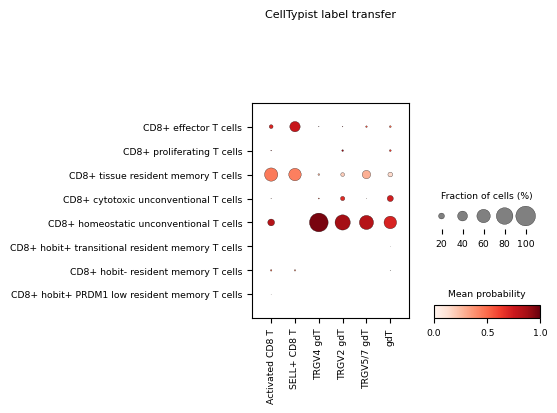

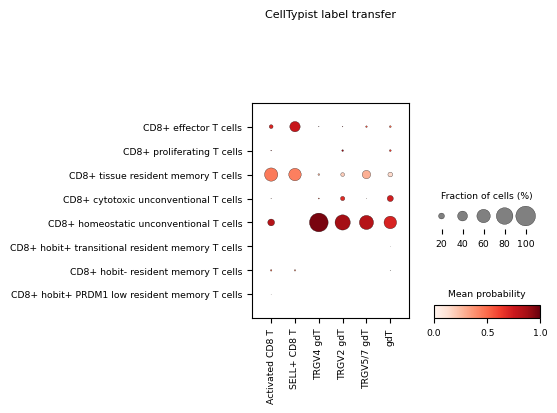

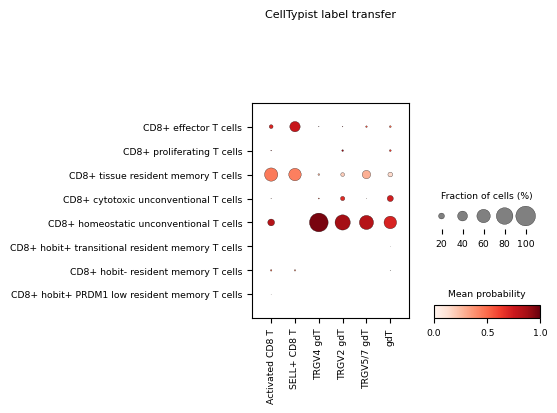

In [34]:
celltypist.dotplot(predictions_cd8, use_as_reference = 'annotation', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd8_gutatlas.png")
celltypist.dotplot(predictions_cd8, use_as_reference = 'annotation', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd8_gutatlas.pdf")
celltypist.dotplot(predictions_cd8, use_as_reference = 'annotation', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd8_gutatlas.svg")

🔬 Input data has 401 cells and 13651 genes
🔗 Matching reference genes in the model
🧬 1190 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


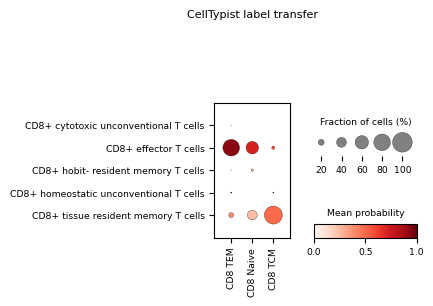

In [35]:
predictions_cd8 = celltypist.annotate(adata2_azimuth_cd8, model=model_cd8, majority_voting=False)
adata_predictions_cd8 = predictions_cd8.to_adata()
celltypist.dotplot(predictions_cd8, use_as_reference = 'cell_anno_azimuth', use_as_prediction = 'predicted_labels',cmap='Reds') 

In [36]:


# Example: Access the predicted_labels DataFrame
predicted_labels = predictions_cd8.predicted_labels

# Get the existing categories from adata_own_cd8.obs['leiden_overall']
existing_categories = adata_own_cd8.obs['T_cell_subsets_refined_resi'].unique()

# Ensure the predicted_labels column is categorical
if not pd.api.types.is_categorical_dtype(predicted_labels['predicted_labels']):
    predicted_labels['predicted_labels'] = predicted_labels['predicted_labels'].astype('category')

# Identify categories in adata_own_cd8.obs['leiden_overall'] that are not already in predicted_labels
missing_categories = [category for category in existing_categories if category not in predicted_labels['predicted_labels'].cat.categories]

# Add the missing categories to the predicted_labels column
if missing_categories:
    predicted_labels['predicted_labels'] = predicted_labels['predicted_labels'].cat.add_categories(missing_categories)

# Maintain the original order of categories (existing + new)
all_categories_in_order = list(existing_categories)  # Use existing categories' order
predicted_labels['predicted_labels'] = predicted_labels['predicted_labels'].cat.set_categories(all_categories_in_order, ordered=True)

# Now, assign each missing category to a different row sequentially
for i, new_category in enumerate(missing_categories):
    # Assign the missing category to the i-th row
    predicted_labels.loc[predicted_labels.index[i], 'predicted_labels'] = new_category

# Verify the updated DataFrame
print(f"Added categories: {missing_categories}")
print(predicted_labels['predicted_labels'].cat.categories)  # Show the updated categories
print(predicted_labels.head())  # Check the first few rows
print(predicted_labels['predicted_labels'].unique())  # Verify the unique categories

Added categories: ['CD8+ proliferating T cells', 'CD8+ hobit+ transitional resident memory T cells', 'CD8+ hobit+ PRDM1 low resident memory T cells']
Index(['CD8+ effector T cells', 'CD8+ proliferating T cells',
       'CD8+ tissue resident memory T cells',
       'CD8+ cytotoxic unconventional T cells',
       'CD8+ homeostatic unconventional T cells',
       'CD8+ hobit+ transitional resident memory T cells',
       'CD8+ hobit- resident memory T cells',
       'CD8+ hobit+ PRDM1 low resident memory T cells'],
      dtype='object')
                                    predicted_labels
4                         CD8+ proliferating T cells
7   CD8+ hobit+ transitional resident memory T cells
8      CD8+ hobit+ PRDM1 low resident memory T cells
9                              CD8+ effector T cells
10                             CD8+ effector T cells
['CD8+ proliferating T cells', 'CD8+ hobit+ transitional resident memory T ce..., 'CD8+ hobit+ PRDM1 low resident memory T cells', 'CD8+ effec

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_10102/3857681700.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(predicted_labels['predicted_labels']):


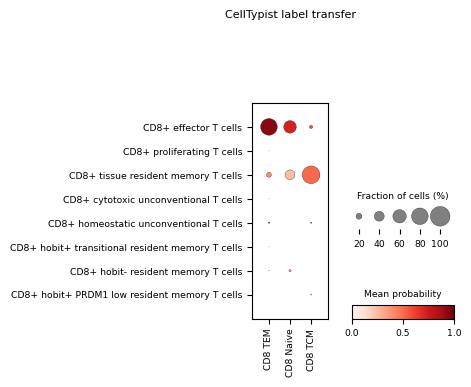

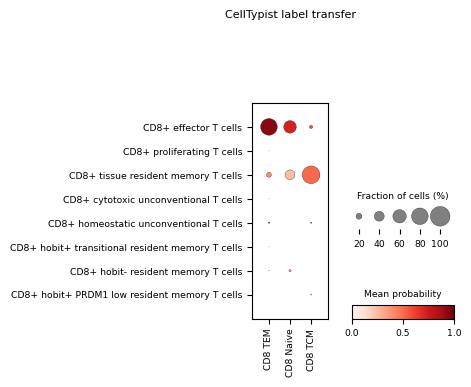

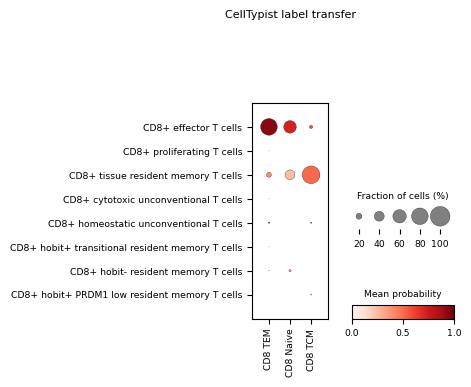

In [37]:
celltypist.dotplot(predictions_cd8, use_as_reference = 'cell_anno_azimuth', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd8_azimuth.png") 
celltypist.dotplot(predictions_cd8, use_as_reference = 'cell_anno_azimuth', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd8_azimuth.pdf") 
celltypist.dotplot(predictions_cd8, use_as_reference = 'cell_anno_azimuth', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd8_azimuth.svg") 

🔬 Input data has 416 cells and 13651 genes


🔗 Matching reference genes in the model
🧬 1190 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


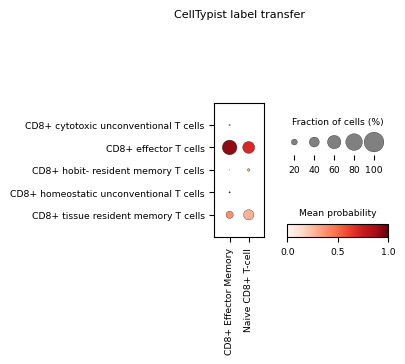

In [38]:
predictions_cd8 = celltypist.annotate(adata2_Novershtern_cd8, model=model_cd8, majority_voting=False)
adata_predictions_cd8 = predictions_cd8.to_adata()
celltypist.dotplot(predictions_cd8, use_as_reference = 'cluster_anno_NovershternPanel', use_as_prediction = 'predicted_labels',cmap='Reds') 

In [39]:
# Example: Access the predicted_labels DataFrame
predicted_labels = predictions_cd8.predicted_labels

# Get the existing categories from adata_own_cd8.obs['leiden_overall']
existing_categories = adata_own_cd8.obs['T_cell_subsets_refined_resi'].unique()

# Ensure the predicted_labels column is categorical
if not pd.api.types.is_categorical_dtype(predicted_labels['predicted_labels']):
    predicted_labels['predicted_labels'] = predicted_labels['predicted_labels'].astype('category')

# Identify categories in adata_own_cd8.obs['leiden_overall'] that are not already in predicted_labels
missing_categories = [category for category in existing_categories if category not in predicted_labels['predicted_labels'].cat.categories]

# Add the missing categories to the predicted_labels column
if missing_categories:
    predicted_labels['predicted_labels'] = predicted_labels['predicted_labels'].cat.add_categories(missing_categories)

# Maintain the original order of categories (existing + new)
all_categories_in_order = list(existing_categories)  # Use existing categories' order
predicted_labels['predicted_labels'] = predicted_labels['predicted_labels'].cat.set_categories(all_categories_in_order, ordered=True)

# Now, assign each missing category to a different row sequentially
for i, new_category in enumerate(missing_categories):
    # Assign the missing category to the i-th row
    predicted_labels.loc[predicted_labels.index[i], 'predicted_labels'] = new_category

# Verify the updated DataFrame
print(f"Added categories: {missing_categories}")
print(predicted_labels['predicted_labels'].cat.categories)  # Show the updated categories
print(predicted_labels.head())  # Check the first few rows
print(predicted_labels['predicted_labels'].unique())  # Verify the unique categories

Added categories: ['CD8+ proliferating T cells', 'CD8+ hobit+ transitional resident memory T cells', 'CD8+ hobit+ PRDM1 low resident memory T cells']
Index(['CD8+ effector T cells', 'CD8+ proliferating T cells',
       'CD8+ tissue resident memory T cells',
       'CD8+ cytotoxic unconventional T cells',
       'CD8+ homeostatic unconventional T cells',
       'CD8+ hobit+ transitional resident memory T cells',
       'CD8+ hobit- resident memory T cells',
       'CD8+ hobit+ PRDM1 low resident memory T cells'],
      dtype='object')
                                   predicted_labels
4                        CD8+ proliferating T cells
6  CD8+ hobit+ transitional resident memory T cells
7     CD8+ hobit+ PRDM1 low resident memory T cells
8               CD8+ tissue resident memory T cells
9                             CD8+ effector T cells
['CD8+ proliferating T cells', 'CD8+ hobit+ transitional resident memory T ce..., 'CD8+ hobit+ PRDM1 low resident memory T cells', 'CD8+ tissue resi

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_10102/961247494.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(predicted_labels['predicted_labels']):


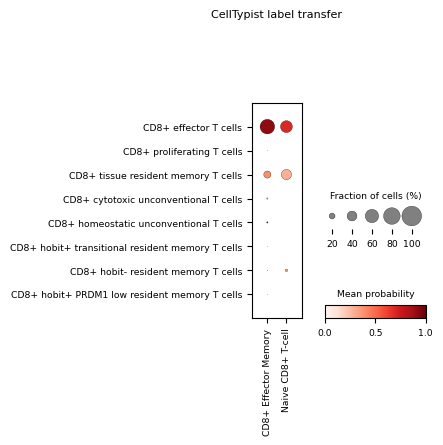

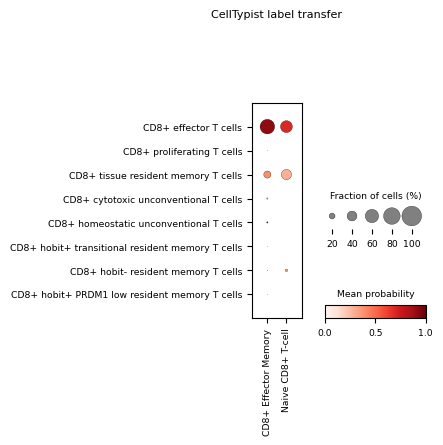

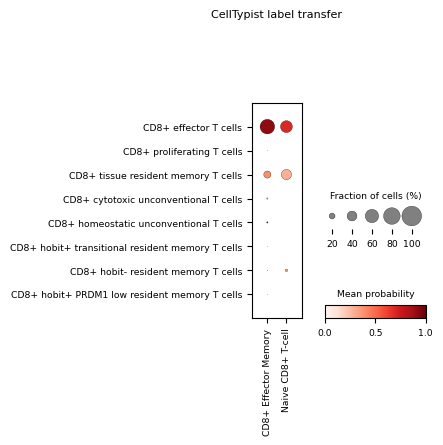

In [40]:
celltypist.dotplot(predictions_cd8, use_as_reference = 'cluster_anno_NovershternPanel', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd8_novershtern.png") 
celltypist.dotplot(predictions_cd8, use_as_reference = 'cluster_anno_NovershternPanel', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd8_novershtern.pdf") 
celltypist.dotplot(predictions_cd8, use_as_reference = 'cluster_anno_NovershternPanel', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd8_novershtern.svg") 

In [41]:


# Directory containing the h5 files
data_dir = GSE152042_RAW_DIR

# Find all h5 files
h5_files = sorted(data_dir.glob("*.h5"))

print(f"Found {len(h5_files)} h5 files:")
for f in h5_files:
    print(f"  - {f.name}")

# Load all h5 files into a dictionary using 10X reader
adata_dict = {}
for file in h5_files:
    print(f"\nLoading {file.name}...")
    adata = sc.read_10x_h5(str(file))
    # Make var_names unique within each dataset
    adata.var_names_make_unique()
    adata_dict[file.stem] = adata
    print(f"  Shape: {adata.shape}")
    print(f"  Obs columns: {adata.obs.columns.tolist()}")
    print(f"  Var columns: {adata.var.columns.tolist()}")

# Option 1: Concatenate all into a single object
print("\n" + "="*50)
print("Concatenating all files...")
adata_combined = sc.concat(adata_dict.values(), axis=0, join='outer')
print(f"Combined shape: {adata_combined.shape}")

# Save the combined object
output_path = data_dir / "GSE152042_combined.h5ad"
adata_combined.write_h5ad(output_path)
print(f"Saved combined object to: {output_path}")

Found 4 h5 files:
  - GSM4600896_filtered_feature_bc_matrix_h1.h5
  - GSM4600897_filtered_feature_bc_matrix_h2.h5
  - GSM4600898_filtered_feature_bc_matrix_p1.h5
  - GSM4600899_filtered_feature_bc_p2.h5

Loading GSM4600896_filtered_feature_bc_matrix_h1.h5...
  Shape: (645, 33538)
  Obs columns: []
  Var columns: ['gene_ids', 'feature_types', 'genome']

Loading GSM4600897_filtered_feature_bc_matrix_h2.h5...
  Shape: (4541, 33538)
  Obs columns: []
  Var columns: ['gene_ids', 'feature_types', 'genome']

Loading GSM4600898_filtered_feature_bc_matrix_p1.h5...
  Shape: (4698, 33538)
  Obs columns: []
  Var columns: ['gene_ids', 'feature_types', 'genome']

Loading GSM4600899_filtered_feature_bc_p2.h5...
  Shape: (3758, 33538)
  Obs columns: []
  Var columns: ['gene_ids', 'feature_types', 'genome']

Concatenating all files...
Combined shape: (13642, 33538)
Saved combined object to: ../../published_data/GSE152042_RAW/GSE152042_combined.h5ad


In [42]:
adata.X.max()

57792.0

In [43]:
adata

AnnData object with n_obs × n_vars = 3758 × 33538
    var: 'gene_ids', 'feature_types', 'genome'

In [44]:
#preprocessing
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [45]:
####Gut single cell atlas to get labels

file_path = GUT_ATLAS_PATH
adata = sc.read_h5ad(file_path)

print(adata)

AnnData object with n_obs × n_vars = 176183 × 36390
    obs: 'sampleID', 'level_1_annot', 'level_2_annot', 'level_3_annot', 'n_counts', 'cell_type_ontology_term_id', 'sourceID', 'study', 'donorID_unified', 'donor_category', 'donor_disease', 'organ_unified', 'age_unified', 'sample_type', 'sample_category', 'sample_retrieval', 'tissue_fraction', 'cell_fraction_unified', 'cell_sorting', 'organ_groups', 'control_vs_disease', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_symbols', 'feature_is_filtered'
    uns: 'default_embedding', 'neighbors_scvi', 'organism_ontology_term_id', 'title', 'umap'
    obsm: 'X_pca', 'X_scvi', 'X_umap'
    obsp: 'neighbors_scvi_

In [46]:
adata.obs

,sampleID,level_1_annot,level_2_annot,level_3_annot,n_counts,cell_type_ontology_term_id,sourceID,study,donorID_unified,donor_category,...,tissue_type,donor_id,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
index,,,,,,,,,,,,,,,,,,,,,
AAGACAAAGAAGTATC-GSM4600896,GSM4600896,T and NK cells,Treg,Treg_IL10,13231.0,CL:0000815,GSM4600898,Caetano2021,D61,control,...,tissue,Healthy 1,regulatory T cell,10x 3' v3,normal,male,gingiva,unknown,adult stage,aK>bnO+hY~
ACTCTCGTCTCCTGTG-GSM4600896,GSM4600896,T and NK cells,Conventional_CD8,Trm/em_CD8,4816.0,CL:0000913,GSM4600898,Caetano2021,D61,control,...,tissue,Healthy 1,"effector memory CD8-positive, alpha-beta T cell",10x 3' v3,normal,male,gingiva,unknown,adult stage,azul-KpQqZ
ATGAAAGCATAACGGG-GSM4600896,GSM4600896,T and NK cells,Treg,Treg_IL10,2154.0,CL:0000815,GSM4600898,Caetano2021,D61,control,...,tissue,Healthy 1,regulatory T cell,10x 3' v3,normal,male,gingiva,unknown,adult stage,1tXnU7+DJ5
ATGCCTCCACAACGTT-GSM4600896,GSM4600896,T and NK cells,Conventional_CD4,Trm_Th17,10144.0,CL:0000899,GSM4600898,Caetano2021,D61,control,...,tissue,Healthy 1,T-helper 17 cell,10x 3' v3,normal,male,gingiva,unknown,adult stage,DnE>6vrCai
ATGCCTCTCAATCTCT-GSM4600896,GSM4600896,T and NK cells,Conventional_CD4,Trm_Th17,9408.0,CL:0000899,GSM4600898,Caetano2021,D61,control,...,tissue,Healthy 1,T-helper 17 cell,10x 3' v3,normal,male,gingiva,unknown,adult stage,y@$yIka7R5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGCGCGTGAGGGTT-GSM5525958,GSM5525958,T and NK cells,Conventional_CD4,Trm_CD4,1680.0,CL:0000897,GSE182270,Uzzan2022,D138,control,...,tissue,204,"CD4-positive, alpha-beta memory T cell",10x 3' v2,normal,female,colon,unknown,29-year-old stage,`#Hxwx<k@K
TTTGCGCTCCAAAGTC-GSM5525958,GSM5525958,T and NK cells,Conventional_CD4,Tnaive/cm_CD4,1788.0,CL:0000895,GSE182270,Uzzan2022,D138,control,...,tissue,204,"naive thymus-derived CD4-positive, alpha-beta ...",10x 3' v2,normal,female,colon,unknown,29-year-old stage,cTdee%241l
TTTGCGCTCGAATGCT-GSM5525958,GSM5525958,T and NK cells,Conventional_CD4,Trm_CD4,2817.0,CL:0000897,GSE182270,Uzzan2022,D138,control,...,tissue,204,"CD4-positive, alpha-beta memory T cell",10x 3' v2,normal,female,colon,unknown,29-year-old stage,cS@67xLo*k


In [47]:
adata_gse = adata[adata.obs.study == 'Jaeger2021']

In [48]:
adata_gse

View of AnnData object with n_obs × n_vars = 34321 × 36390
    obs: 'sampleID', 'level_1_annot', 'level_2_annot', 'level_3_annot', 'n_counts', 'cell_type_ontology_term_id', 'sourceID', 'study', 'donorID_unified', 'donor_category', 'donor_disease', 'organ_unified', 'age_unified', 'sample_type', 'sample_category', 'sample_retrieval', 'tissue_fraction', 'cell_fraction_unified', 'cell_sorting', 'organ_groups', 'control_vs_disease', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_symbols', 'feature_is_filtered'
    uns: 'default_embedding', 'neighbors_scvi', 'organism_ontology_term_id', 'title', 'umap'
    obsm: 'X_pca', 'X_scvi', 'X_umap'
    obsp: 'neighbor

In [49]:
# Count cells per study
study_counts = adata.obs['study'].value_counts()
print("Cells per study:")
print(study_counts)
print(f"\nTotal studies: {len(study_counts)}")
print(f"Caetano2021 cells: {study_counts.get('Caetano2021', 0)}")
print(f"Caetano2021 % of total: {(study_counts.get('Caetano2021', 0) / adata.n_obs * 100):.2f}%")

Cells per study:
study
Jaeger2021             34321
Elmentaite2021         28745
James2020              16495
Kim2022                14389
Adult_unpublished      11922
Martin2019             11902
Huang2019               8996
Williams2021            8049
Uzzan2022               7906
He2020GenomeBio         7430
Chen2021                6026
Yu2021                  4601
Holloway2021            3868
Lee2020                 3069
Preterm_unpublished     2199
Li2019                  1456
Madissoon2019           1100
Dominguez2022           1079
CostaDaSilva2022        1006
Jeong2021                701
Parikh2019               608
Caetano2021              144
Pagella2021               84
Wang2020                  68
Kinchen2018               19
Kong2023                   0
Fitzpatrick2023            0
Name: count, dtype: int64

Total studies: 27
Caetano2021 cells: 144
Caetano2021 % of total: 0.08%


In [50]:

### Tar all the files in the directory and extract them to a new directory
# Directory containing the tar.gz files
data_dir = GSE157477_RAW_DIR
extract_dir = data_dir / "extracted"

# Create extraction directory
extract_dir.mkdir(exist_ok=True)

# Find all tar.gz files
tar_files = sorted(data_dir.glob("*.tar.gz"))

print(f"Found {len(tar_files)} compressed files")
print("="*60)

adata_dict = {}

for tar_file in tar_files:
    sample_name = tar_file.stem.replace("_filtered_gene_bc_matrices.tar", "")
    print(f"\nProcessing {sample_name}...")
    
    # Extract tar.gz
    sample_extract_dir = extract_dir / sample_name
    sample_extract_dir.mkdir(exist_ok=True)
    
    with tarfile.open(tar_file, 'r:gz') as tar:
        tar.extractall(sample_extract_dir)

Found 11 compressed files

Processing GSM4766839_N-7420-4...

Processing GSM4766840_N-1425-3...

Processing GSM4766841_CD-1813-4...

Processing GSM4766842_CD-1813-6...

Processing GSM4766843_CD-1818-3...

Processing GSM4766844_CD-1818-5...

Processing GSM4766845_N-7420-2...

Processing GSM4766846_N-1425-1...

Processing GSM4766847_CD-1813-1...

Processing GSM4766848_CD-1813-2...

Processing GSM4766849_CD-1818-1...


In [51]:

### load in files 
# Directory with extracted files to get raw counts 
extract_dir = GSE157477_RAW_DIR / 'extracted'

# Find all sample directories
sample_dirs = sorted([d for d in extract_dir.iterdir() if d.is_dir() and d.name.startswith('GSM')])

print(f"Found {len(sample_dirs)} sample directories")
print("="*60)

adata_dict = {}

for sample_dir in sample_dirs:
    sample_name = sample_dir.name
    print(f"\nProcessing {sample_name}...")
    
    # Find the genome-specific matrix directory (GRCh38, GRCm38, etc.)
    matrix_dirs = list(sample_dir.glob("filtered_gene_bc_matrices/*/"))
    
    if matrix_dirs:
        matrix_dir = matrix_dirs[0]
        genome_name = matrix_dir.parent.parent.name
        print(f"  Found matrix in: {matrix_dir.name}")
        
        try:
            # Read 10X matrix
            adata = sc.read_10x_mtx(matrix_dir)
            adata.obs_names_make_unique()
            adata.var_names_make_unique()
            
            # Add metadata
            adata.obs['sample'] = sample_name
            
            adata_dict[sample_name] = adata
            print(f"  ✓ Loaded: {adata.shape[0]} cells x {adata.shape[1]} genes")
        except Exception as e:
            print(f"  ✗ Error: {e}")
    else:
        print(f"  No matrix directory found!")

print("\n" + "="*60)
print("SUMMARY:")
print(f"Successfully loaded {len(adata_dict)}/{len(sample_dirs)} samples\n")

if adata_dict:
    for name in sorted(adata_dict.keys()):
        shape = adata_dict[name].shape
        print(f"  {name}: {shape[0]:6d} cells x {shape[1]:6d} genes")
    
    # Concatenate all samples
    print("\n" + "="*60)
    print("Concatenating all samples...")
    adata_combined = anndata.concat(adata_dict.values(), axis=0, join='outer')
    print(f"Combined shape: {adata_combined.shape[0]} cells x {adata_combined.shape[1]} genes")
    
    # Save combined object
    output_path = extract_dir.parent / "GSE157477_combined.h5ad"
    adata_combined.write_h5ad(output_path)
    print(f"✓ Saved to: {output_path}")


Found 11 sample directories

Processing GSM4766839_N-7420-4...
  Found matrix in: GRCh38
  ✓ Loaded: 7499 cells x 33694 genes

Processing GSM4766840_N-1425-3...
  Found matrix in: GRCh38
  ✓ Loaded: 4110 cells x 33694 genes

Processing GSM4766841_CD-1813-4...
  Found matrix in: GRCh38
  ✓ Loaded: 5628 cells x 33694 genes

Processing GSM4766842_CD-1813-6...
  Found matrix in: GRCh38
  ✓ Loaded: 5634 cells x 33694 genes

Processing GSM4766843_CD-1818-3...
  Found matrix in: GRCh38
  ✓ Loaded: 7638 cells x 33694 genes

Processing GSM4766844_CD-1818-5...
  Found matrix in: GRCh38
  ✓ Loaded: 7700 cells x 33694 genes

Processing GSM4766845_N-7420-2...
  Found matrix in: GRCh38
  ✓ Loaded: 6828 cells x 33694 genes

Processing GSM4766846_N-1425-1...
  Found matrix in: GRCh38
  ✓ Loaded: 5370 cells x 33694 genes

Processing GSM4766847_CD-1813-1...
  Found matrix in: GRCh38
  ✓ Loaded: 2689 cells x 33694 genes

Processing GSM4766848_CD-1813-2...
  Found matrix in: GRCh38
  ✓ Loaded: 4550 cells 

... storing 'sample' as categorical


Combined shape: 60110 cells x 33694 genes
✓ Saved to: ../../published_data/GSE157477_RAW/GSE157477_combined.h5ad


In [52]:
adata_combined.X.max()

10107.0

In [53]:
adata_combined

AnnData object with n_obs × n_vars = 60110 × 33694
    obs: 'sample'

In [54]:
adata_gse.obs.index

Index(['AAACCTGCAAGCTGTT-GSM4766840', 'AAACCTGCAAGTACCT-GSM4766840',
       'AAACCTGCAGTCCTTC-GSM4766840', 'AAACCTGGTCTGCCAG-GSM4766840',
       'AAACCTGTCGCTAGCG-GSM4766840', 'AAACGGGAGACTAGGC-GSM4766840',
       'AAACGGGAGATGGGTC-GSM4766840', 'AAACGGGAGTCTCCTC-GSM4766840',
       'AAACGGGCAACCGCCA-GSM4766840', 'AAAGATGAGGACAGCT-GSM4766840',
       ...
       'TTTGGTTTCAGTTCGA-GSM4766848', 'TTTGTCAAGTATTGGA-GSM4766848',
       'TTTGTCACAAGGACTG-GSM4766848', 'TTTGTCAGTATAGGTA-GSM4766848',
       'TTTGTCAGTATGCTTG-GSM4766848', 'TTTGTCAGTCGAAAGC-GSM4766848',
       'TTTGTCAGTGCAGGTA-GSM4766848', 'TTTGTCATCAGGATCT-GSM4766848',
       'TTTGTCATCGTCACGG-GSM4766848', 'TTTGTCATCTACGAGT-GSM4766848'],
      dtype='object', name='index', length=34321)

In [55]:
adata_combined.obs.index

Index(['AAACCTGAGACAAAGG-1', 'AAACCTGAGATCCTGT-1', 'AAACCTGAGCAGGTCA-1',
       'AAACCTGAGGTCGGAT-1', 'AAACCTGAGTGTGAAT-1', 'AAACCTGAGTGTTTGC-1',
       'AAACCTGCAATAGAGT-1', 'AAACCTGCACGAAAGC-1', 'AAACCTGCACGCATCG-1',
       'AAACCTGCATGCCTTC-1',
       ...
       'TTTGGTTTCCTTAATC-1', 'TTTGGTTTCGGCCGAT-1', 'TTTGTCAAGAATGTGT-1',
       'TTTGTCAAGACTGGGT-1', 'TTTGTCAAGTTACCCA-1', 'TTTGTCACAATCGAAA-1',
       'TTTGTCACACCATCCT-1', 'TTTGTCAGTTCCCGAG-1', 'TTTGTCATCAAGGCTT-1',
       'TTTGTCATCGGCGGTT-1'],
      dtype='object', length=60110)

In [56]:

# Clean indices by removing everything after "-"
adata_gse_clean_index = adata_gse.obs.index.str.split('-').str[0]
adata_combined_clean_index = adata_combined.obs.index.str.split('-').str[0]

# Find overlapping cells
overlapping_cells = set(adata_gse_clean_index) & set(adata_combined_clean_index)

print(f"Total cells in adata_gse: {len(adata_gse_clean_index)}")
print(f"Total cells in adata_combined: {len(adata_combined_clean_index)}")
print(f"Overlapping cells: {len(overlapping_cells)}")

# Create mapping dictionaries
# Map cleaned index to full index
gse_clean_to_full = dict(zip(adata_gse_clean_index, adata_gse.obs.index))
combined_clean_to_full = dict(zip(adata_combined_clean_index, adata_combined.obs.index))

# Map cleaned index to level_3_annot
gse_clean_to_annot = dict(zip(adata_gse_clean_index, adata_gse.obs['level_3_annot']))

# Initialize new column in adata_combined with NaN
adata_combined.obs['level_3_annot'] = pd.NA

# Transfer annotations for overlapping cells
for clean_idx in overlapping_cells:
    combined_full_idx = combined_clean_to_full[clean_idx]
    annotation = gse_clean_to_annot[clean_idx]
    adata_combined.obs.loc[combined_full_idx, 'level_3_annot'] = annotation

# Summary
print(f"\nAnnotations transferred for {len(overlapping_cells)} cells")
print(f"\nAnnotation distribution in transferred cells:")
print(adata_combined.obs['level_3_annot'].value_counts())
print(f"\nCells with missing annotations: {adata_combined.obs['level_3_annot'].isna().sum()}")


Total cells in adata_gse: 34321
Total cells in adata_combined: 60110
Overlapping cells: 33520

Annotations transferred for 33520 cells

Annotation distribution in transferred cells:
level_3_annot
Trm_CD8          7005
Trm_CD4          4944
gdT              4400
Trm/em_CD8       4387
Trm_Th17         3592
Tnaive/cm_CD4    3149
Tfh              2434
Treg_IL10        2177
Tfh_naive        1310
Treg              725
Tnaive/cm_CD8     286
NK_CD16           203
MAIT              203
T/NK_cycling      180
gdT_naive         178
NK_CD56bright      82
ILC3               10
Name: count, dtype: int64

Cells with missing annotations: 24845


In [57]:
adata_combined = adata_combined[~adata_combined.obs['level_3_annot'].isna()].copy()
adata_combined

AnnData object with n_obs × n_vars = 35265 × 33694
    obs: 'sample', 'level_3_annot'

In [58]:
#preprocessing
sc.pp.filter_cells(adata_combined, min_genes=200)
sc.pp.filter_genes(adata_combined, min_cells=3)

sc.pp.normalize_total(adata_combined, target_sum=1e4)
sc.pp.log1p(adata_combined)

In [59]:
# Reset indices and clean up the level_3_annot column
adata_combined.obs = adata_combined.obs.reset_index(drop=True)
adata_combined.obs.index = adata_combined.obs_names

# Ensure level_3_annot is a clean string column
adata_combined.obs['level_3_annot'] = adata_combined.obs['level_3_annot'].astype(str).values

cd4_annotations = ['Trm_CD4', 'Trm_Th17', 'Tnaive/cm_CD4','Tfh','Treg_IL10','Tfh_naive','Treg']
adata_Jaeger_cd4 = adata_combined[adata_combined.obs['level_3_annot'].isin(cd4_annotations)].copy()

# Filter for CD8 annotations (Activated CD8 T, SELL+ CD8 T, gdT cells)
cd8_annotations = ['Trm_CD8', 'gdT', 'Trm/em_CD8', 'Tnaive/cm_CD8','gdT_naive']
adata_Jaeger_cd8 = adata_combined[adata_combined.obs['level_3_annot'].isin(cd8_annotations)].copy()

# Ensure both have clean indices
adata_Jaeger_cd4.obs = adata_Jaeger_cd4.obs.reset_index(drop=True)
adata_Jaeger_cd4.obs.index = adata_Jaeger_cd4.obs_names
adata_Jaeger_cd8.obs = adata_Jaeger_cd8.obs.reset_index(drop=True)
adata_Jaeger_cd8.obs.index = adata_Jaeger_cd8.obs_names

print(f"adata_Jaeger_cd4: {adata_Jaeger_cd4.shape}")
print(f"level_3_annot dtype: {adata_Jaeger_cd4.obs['level_3_annot'].dtype}")


adata_Jaeger_cd4: (18331, 20136)
level_3_annot dtype: object


🔬 Input data has 18331 cells and 20136 genes
🔗 Matching reference genes in the model
🧬 574 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


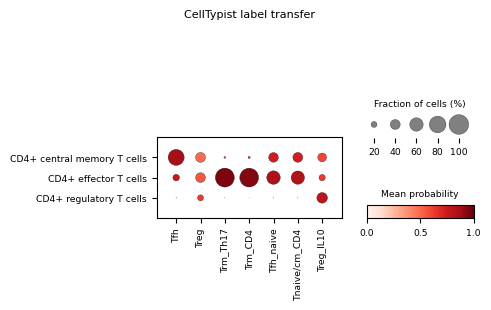

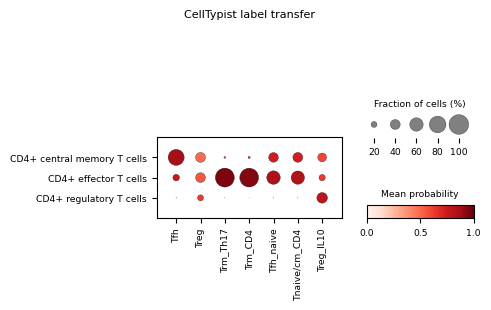

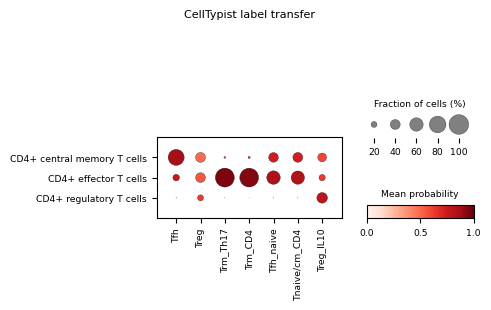

In [60]:
predictions_cd4 = celltypist.annotate(adata_Jaeger_cd4, model=model_cd4, majority_voting=False)

celltypist.dotplot(predictions_cd4, use_as_reference = 'level_3_annot', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd4_jaeger.png") 
celltypist.dotplot(predictions_cd4, use_as_reference = 'level_3_annot', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd4_jaeger.pdf") 
celltypist.dotplot(predictions_cd4, use_as_reference = 'level_3_annot', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd4_jaeger.svg") 

In [61]:
predictions_cd8 = celltypist.annotate(adata_Jaeger_cd8, model=model_cd8, majority_voting=False)


🔬 Input data has 16256 cells and 20136 genes
🔗 Matching reference genes in the model
🧬 1184 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


In [62]:
# Example: Access the predicted_labels DataFrame
predicted_labels = predictions_cd8.predicted_labels

# Get the existing categories from adata_own_cd8.obs['leiden_overall']
existing_categories = adata_own_cd8.obs['T_cell_subsets_refined_resi'].unique()

# Ensure the predicted_labels column is categorical
if not pd.api.types.is_categorical_dtype(predicted_labels['predicted_labels']):
    predicted_labels['predicted_labels'] = predicted_labels['predicted_labels'].astype('category')

# Identify categories in adata_own_cd8.obs['leiden_overall'] that are not already in predicted_labels
missing_categories = [category for category in existing_categories if category not in predicted_labels['predicted_labels'].cat.categories]

# Add the missing categories to the predicted_labels column
if missing_categories:
    predicted_labels['predicted_labels'] = predicted_labels['predicted_labels'].cat.add_categories(missing_categories)

# Maintain the original order of categories (existing + new)
all_categories_in_order = list(existing_categories)  # Use existing categories' order
predicted_labels['predicted_labels'] = predicted_labels['predicted_labels'].cat.set_categories(all_categories_in_order, ordered=True)

# Now, assign each missing category to a different row sequentially
for i, new_category in enumerate(missing_categories):
    # Assign the missing category to the i-th row
    predicted_labels.loc[predicted_labels.index[i], 'predicted_labels'] = new_category

# Verify the updated DataFrame
print(f"Added categories: {missing_categories}")
print(predicted_labels['predicted_labels'].cat.categories)  # Show the updated categories
print(predicted_labels.head())  # Check the first few rows
print(predicted_labels['predicted_labels'].unique())  # Verify the unique categories

Added categories: []
Index(['CD8+ effector T cells', 'CD8+ proliferating T cells',
       'CD8+ tissue resident memory T cells',
       'CD8+ cytotoxic unconventional T cells',
       'CD8+ homeostatic unconventional T cells',
       'CD8+ hobit+ transitional resident memory T cells',
       'CD8+ hobit- resident memory T cells',
       'CD8+ hobit+ PRDM1 low resident memory T cells'],
      dtype='object')
                      predicted_labels
0                CD8+ effector T cells
1  CD8+ tissue resident memory T cells
2  CD8+ tissue resident memory T cells
3                CD8+ effector T cells
4                CD8+ effector T cells
['CD8+ effector T cells', 'CD8+ tissue resident memory T cells', 'CD8+ homeostatic unconventional T cells', 'CD8+ hobit- resident memory T cells', 'CD8+ proliferating T cells', 'CD8+ cytotoxic unconventional T cells', 'CD8+ hobit+ PRDM1 low resident memory T cells', 'CD8+ hobit+ transitional resident memory T ce...]
Categories (8, object): ['CD8+ effect

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_10102/961247494.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(predicted_labels['predicted_labels']):


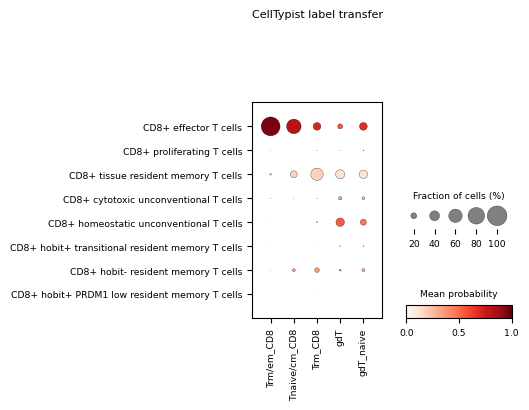

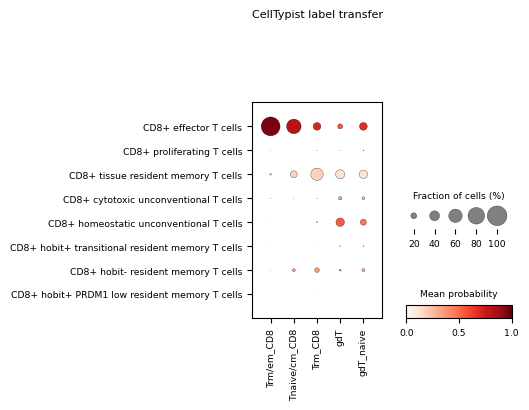

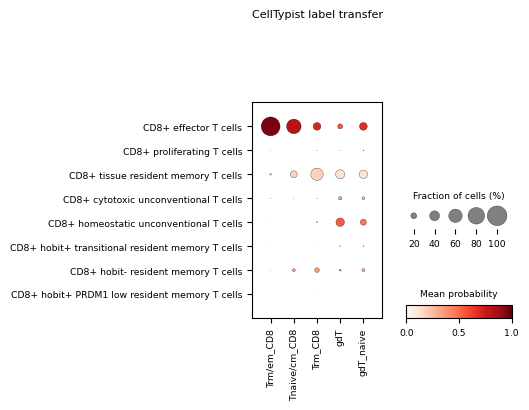

In [63]:
celltypist.dotplot(predictions_cd8, use_as_reference = 'level_3_annot', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd8_jaeger.png") 
celltypist.dotplot(predictions_cd8, use_as_reference = 'level_3_annot', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd8_jaeger.pdf") 
celltypist.dotplot(predictions_cd8, use_as_reference = 'level_3_annot', use_as_prediction = 'predicted_labels',cmap='Reds', save = "cd8_jaeger.svg") 